In [1]:
import sys
sys.path.append('/PATH/TO/VAPOR/vapor')

In [2]:
from utilities import *
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv
from scipy import stats

In [3]:
data_path = '../demo/Cyclic_4096_100_T5_g15.0_g210.0_mud0_sd0.5_mua0_sa0.5_rs42.h5ad'
model_path = '../demo/pretrained_cyclic.pth'

# Define model parameters
latent_dim = 2
encoder_dims = [256, 64, 8]
decoder_dims = [8, 64, 256]
psi_M = 1

# Construct adata_VAPOR
adata_list = construct_VAPOR_adata(
    data_path,
    model_path,
    latent_dim=latent_dim,
    encoder_dims=encoder_dims,
    decoder_dims=decoder_dims,
    psi_M=psi_M
)
adata_VAPOR, adata = adata_list
adata_VAPOR

Using device: cpu
Using device: cpu


AnnData object with n_obs × n_vars = 4096 × 2
    obs: 't'
    obsm: 'X_mu', 'X_z'
    layers: 'mu1_psi0', 'v_psi0'

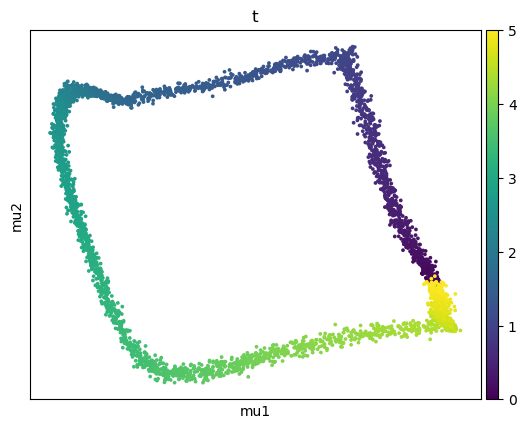

In [4]:
sc.pl.embedding(adata_VAPOR,color=['t'],basis ='mu')

In [5]:
adata_VAPOR.layers['mu']=adata_VAPOR.obsm['X_mu']
sc.pp.neighbors(adata_VAPOR,use_rep='X_mu', random_state=0,n_neighbors=10)

In [6]:
v_layers = [key for key in adata_VAPOR.layers.keys() if key.startswith('v_psi')]
for vkey in sorted(v_layers):
    scv.tl.velocity_graph(adata_VAPOR, vkey=vkey, xkey='mu')

computing velocity graph (using 1/48 cores)


  0%|          | 0/4096 [00:00<?, ?cells/s]

    finished (0:00:11) --> added 
    'v_psi0_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:06) --> added
    'v_psi0_mu', embedded velocity vectors (adata.obsm)


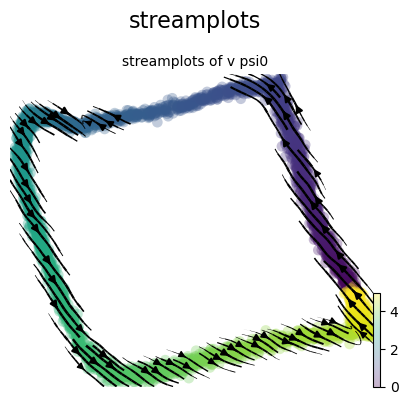

In [7]:
n_plots = len(v_layers)
figsize_per_plot=(4, 4)
n_cols = int(np.ceil(np.sqrt(n_plots)))
n_rows = int(np.ceil(n_plots / n_cols))

fig_width = figsize_per_plot[0] * n_cols
fig_height = figsize_per_plot[1] * n_rows

fig, axs = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
fig.suptitle('streamplots', fontsize=16)

if n_plots == 1:
    axs = np.array([[axs]])
elif n_rows == 1:
    axs = axs.reshape(1, -1)
elif n_cols == 1:
    axs = axs.reshape(-1, 1)

axs = axs.flatten()
for i, psi in enumerate(v_layers):
    scv.pl.velocity_embedding_stream(adata_VAPOR, 
                                     vkey=psi, 
                                     basis='mu', 
                                     color='t',
                                     ax=axs[i], 
                                     show=False,
                                     title=f'streamplots of {psi}')
plt.tight_layout()
plt.show()

In [8]:
condition = (adata.obs['t']==0.0)
root_key = np.where(condition)[0][0]

for vkey in sorted(v_layers):
    adata_VAPOR.obsp[f'{vkey}_tran_mat'] = compute_transition_matrix(adata_VAPOR.obsm['X_mu'], adata_VAPOR.obsm[f'{vkey}_mu'])
    adata_VAPOR.obs[f'{vkey}_pseudotime'] = compute_pseudotime(adata_VAPOR.obsp[f'{vkey}_tran_mat'])

Using specified start cell: 0


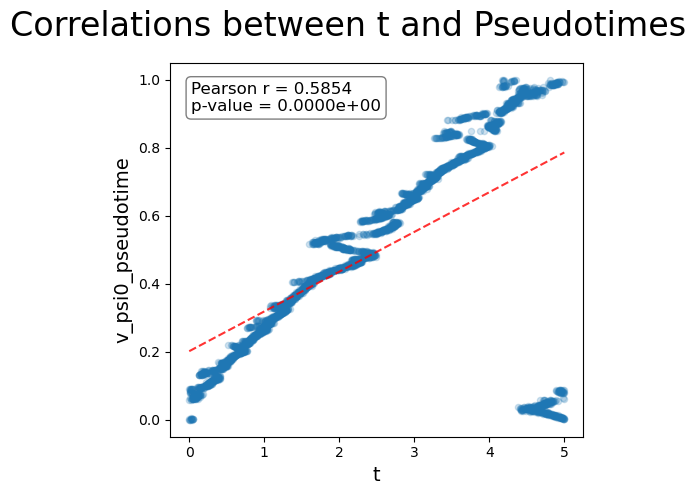

In [9]:
pseudotimes = [vkey+'_pseudotime' for vkey in v_layers]

n_plots = len(pseudotimes)
fig, axs = plt.subplots(1, n_plots, figsize=(5*n_plots, 5), dpi=100)
fig.suptitle('Correlations between t and Pseudotimes', fontsize=24)

if n_plots == 1:
    axs = np.array([[axs]])
elif n_rows == 1:
    axs = axs.reshape(1, -1)
elif n_cols == 1:
    axs = axs.reshape(-1, 1)
    
axs = axs.flatten()
for i, pt in enumerate(pseudotimes):
    correlation, p_value = stats.pearsonr(adata_VAPOR.obs['t'], adata_VAPOR.obs[pt])
    axs[i].scatter(adata_VAPOR.obs['t'], adata_VAPOR.obs[pt], alpha=0.2, s=20)
    axs[i].set_xlabel('t', fontsize=14)
    axs[i].set_ylabel(pt, fontsize=14)
    text_box = f'Pearson r = {correlation:.4f}\np-value = {p_value:.4e}'
    axs[i].text(0.05, 0.95, text_box, transform=axs[i].transAxes, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize=12)
    z = np.polyfit(adata_VAPOR.obs['t'], adata_VAPOR.obs[pt], 1)
    p = np.poly1d(z)
    axs[i].plot(adata_VAPOR.obs['t'], p(adata_VAPOR.obs['t']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

In [10]:
import scanpy.external as sce
import palantir

condition = (adata.obs['t']==0.0)
root_key = np.where(condition)[0][0]

sc.tl.pca(adata)
sc.pp.neighbors(adata)

# palantir
sce.tl.palantir(adata)
pr_res = sce.tl.palantir_results(
    adata,
    early_cell=adata.obs_names[root_key],
    ms_data='X_palantir_multiscale',)
adata.obs['pr_pseudotime']=pr_res.pseudotime

# dpt
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, use_rep="X_diffmap")
adata.uns["iroot"] = np.flatnonzero(condition)[0]
sc.tl.dpt(adata)
adata.uns["iroot"] = np.flatnonzero(condition)[0]
sc.tl.dpt(adata)

Sampling and flocking waypoints...
Time for determining waypoints: 0.012845865885416667 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 3.715364960829417 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


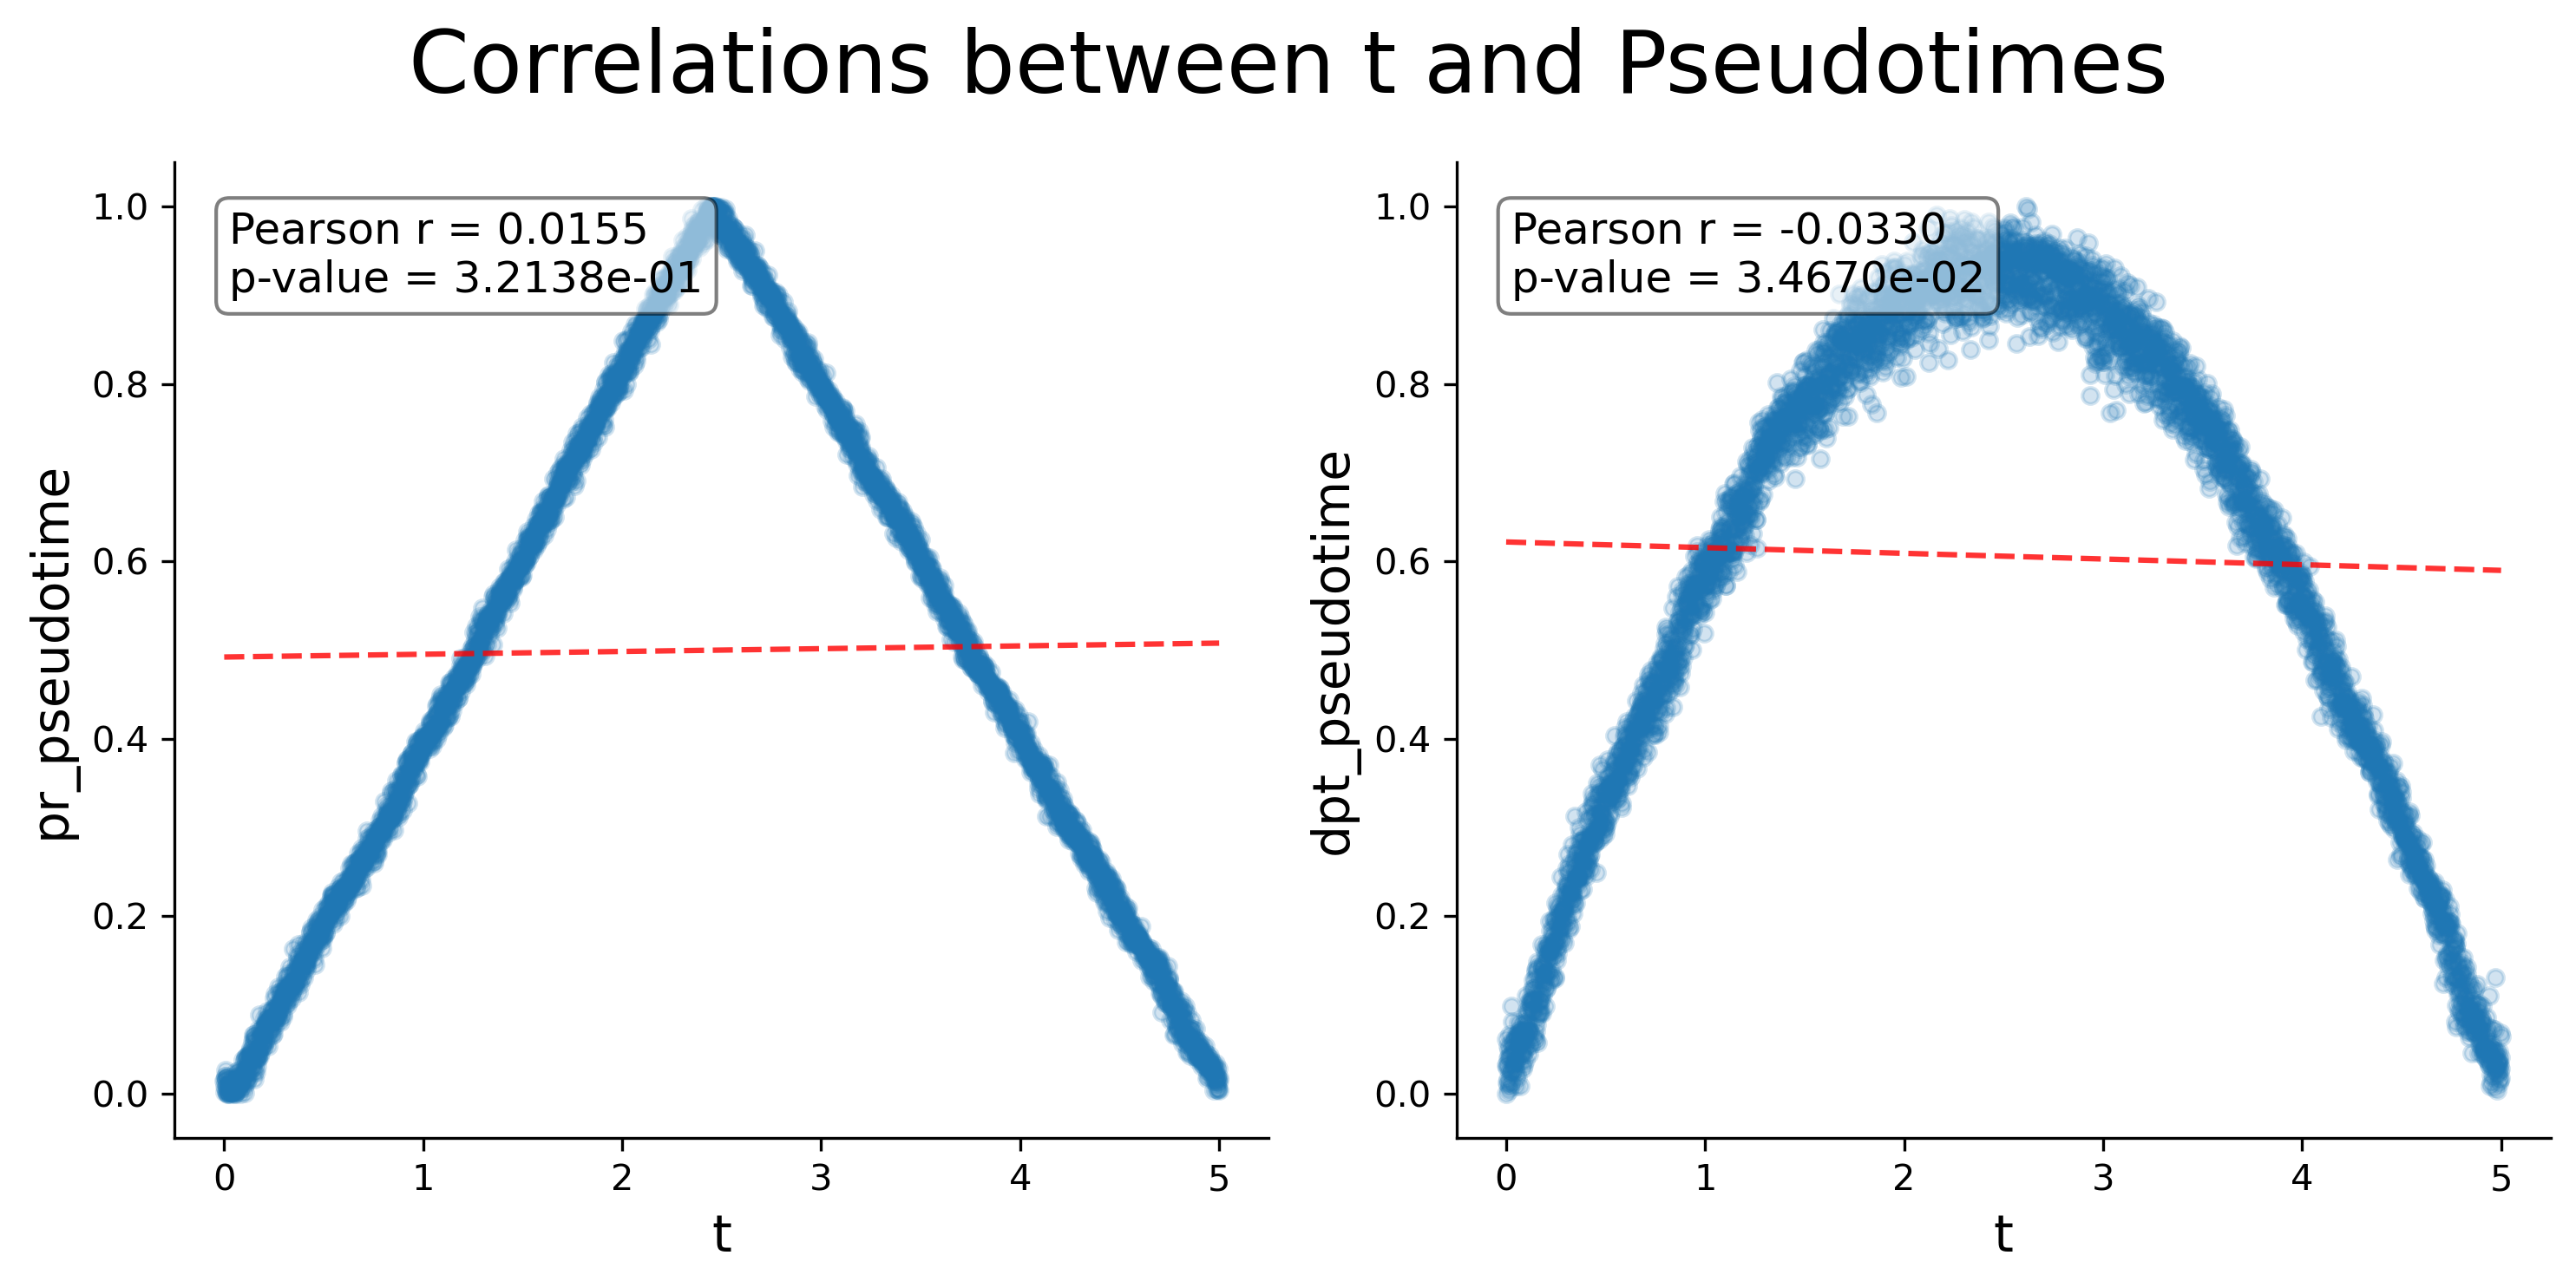

In [11]:
pseudotimes = ['pr_pseudotime', 'dpt_pseudotime']

n_plots = len(pseudotimes)
fig, axs = plt.subplots(1, n_plots, figsize=(5*n_plots, 5), dpi=300)
fig.suptitle('Correlations between t and Pseudotimes', fontsize=24)

if n_plots == 1:
    axs = np.array([[axs]])
elif n_rows == 1:
    axs = axs.reshape(1, -1)
elif n_cols == 1:
    axs = axs.reshape(-1, 1)
    
axs = axs.flatten()
for i, pt in enumerate(pseudotimes):
    correlation, p_value = stats.pearsonr(adata.obs['t'], adata.obs[pt])
    axs[i].scatter(adata.obs['t'], adata.obs[pt], alpha=0.2, s=20)
    axs[i].set_xlabel('t', fontsize=14)
    axs[i].set_ylabel(pt, fontsize=14)
    text_box = f'Pearson r = {correlation:.4f}\np-value = {p_value:.4e}'
    axs[i].text(0.05, 0.95, text_box, transform=axs[i].transAxes, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize=12)
    z = np.polyfit(adata.obs['t'], adata.obs[pt], 1)
    p = np.poly1d(z)
    axs[i].plot(adata.obs['t'], p(adata.obs['t']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()